<a href="https://colab.research.google.com/github/rosnaaidiploma-web/Rosnaelizabeth/blob/main/5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset shape: (49, 6)

Columns: Index(['Crop', 'State', 'Cost of Cultivation (`/Hectare) A2+FL',
       'Cost of Cultivation (`/Hectare) C2',
       'Cost of Production (`/Quintal) C2', 'Yield (Quintal/ Hectare) '],
      dtype='object')

First 5 rows:
     Crop           State  Cost of Cultivation (`/Hectare) A2+FL  \
0  ARHAR   Uttar Pradesh                                9794.05   
1  ARHAR       Karnataka                               10593.15   
2  ARHAR         Gujarat                               13468.82   
3  ARHAR  Andhra Pradesh                               17051.66   
4  ARHAR     Maharashtra                               17130.55   

   Cost of Cultivation (`/Hectare) C2  Cost of Production (`/Quintal) C2  \
0                            23076.74                            1941.55   
1                            16528.68                            2172.46   
2                            19551.90                            1898.30   
3                            24171.65 

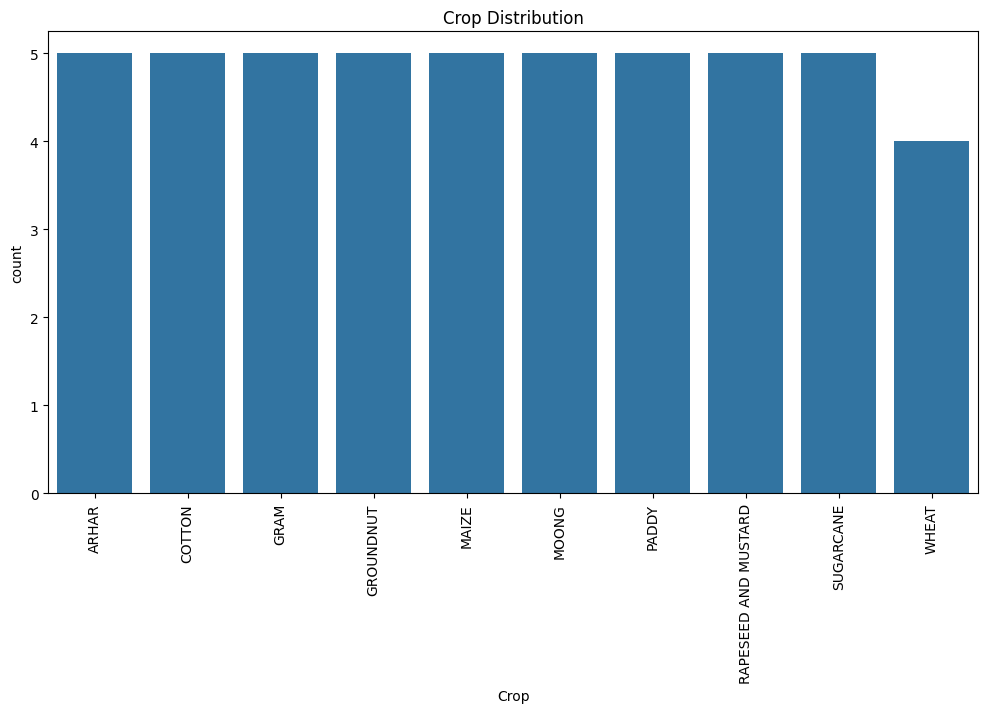

/tmp/ipykernel_2768/3474698364.py:57: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x="State", y="Yield (Quintal/ Hectare) ", ci=None) # Corrected column name


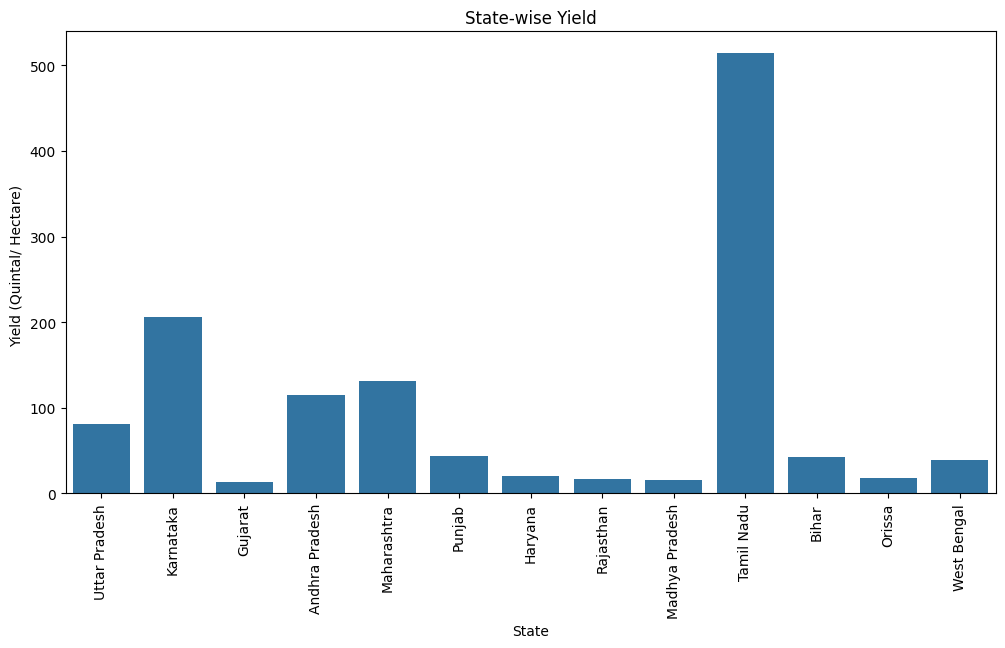


Random Forest Performance:
RMSE: 62.551599522426336
R2 Score: 0.9566879970946721

XGBoost Performance:
RMSE: 71.73234805172213
R2 Score: 0.9430411093281322


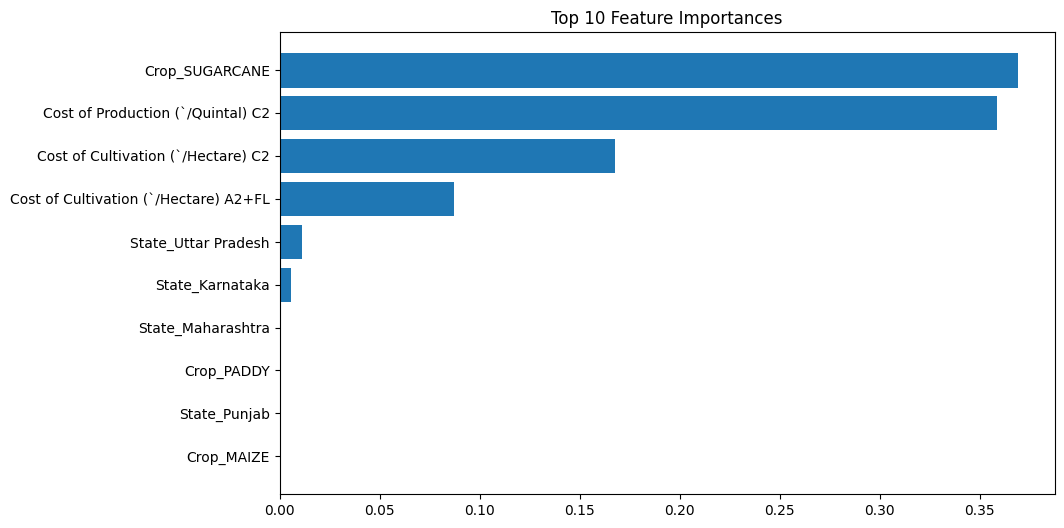

In [ ]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import zipfile
import io

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from xgboost import XGBRegressor, XGBClassifier

# Step 2: Load dataset
# URL for the Google Drive file (nested ZIP)
url = "https://drive.google.com/file/d/1zfqvs8-mAO6E0JpgvhBdueNx8Th03pUp/view?usp=sharing"
# Convert the Google Drive URL to a direct download URL
dl_url = "https://drive.google.com/uc?id=" + url.split("/")[-2]

# Download the outer ZIP file
response = requests.get(dl_url, stream=True)
outer_zip_file = io.BytesIO(response.content)

# Extract the inner ZIP file from the outer ZIP
with zipfile.ZipFile(outer_zip_file, 'r') as outer_zip:
    # Find the name of the inner zip file
    inner_zip_name = [name for name in outer_zip.namelist() if name.endswith('.zip')][0]
    inner_zip_data = outer_zip.read(inner_zip_name)

# Extract the CSV from the inner ZIP file
with zipfile.ZipFile(io.BytesIO(inner_zip_data), 'r') as inner_zip:
    # Find the name of the CSV file
    csv_file_name = [name for name in inner_zip.namelist() if name.endswith('.csv')][0]
    with inner_zip.open(csv_file_name) as csv_file:
        df = pd.read_csv(csv_file, encoding='latin1', on_bad_lines='skip', engine='python')

# Step 3: Explore dataset
print("Dataset shape:", df.shape)
print("\nColumns:", df.columns)
print("\nFirst 5 rows:\n", df.head())

# Step 4: Data Cleaning
df = df.dropna()   # remove missing values
# Optional: unify units, normalize numeric columns
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].astype(float)

# Step 5: Exploratory Data Analysis (EDA)
plt.figure(figsize=(12,6))
sns.countplot(data=df, x="Crop")
plt.xticks(rotation=90)
plt.title("Crop Distribution")
plt.show()

plt.figure(figsize=(12,6))
sns.barplot(data=df, x="State", y="Yield (Quintal/ Hectare) ", ci=None) # Corrected column name
plt.xticks(rotation=90)
plt.title("State-wise Yield") # Corrected title
plt.show()

# Step 6: Feature Engineering
df_encoded = pd.get_dummies(df, columns=['Crop', 'State'], drop_first=True) # Corrected columns for get_dummies

# Step 7: Define features and target
X = df_encoded.drop("Yield (Quintal/ Hectare) ", axis=1)
y = df_encoded["Yield (Quintal/ Hectare) "]
task = "regression"

# Step 8: Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 9: Model Building
if task == "regression":
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)
    rf_preds = rf_model.predict(X_test)

    xgb_model = XGBRegressor(n_estimators=100, random_state=42)
    xgb_model.fit(X_train, y_train)
    xgb_preds = xgb_model.predict(X_test)

    # Step 10: Evaluation
    print("\nRandom Forest Performance:")
    print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_preds))) # Corrected RMSE calculation
    print("R2 Score:", r2_score(y_test, rf_preds))

    print("\nXGBoost Performance:")
    print("RMSE:", np.sqrt(mean_squared_error(y_test, xgb_preds))) # Corrected RMSE calculation
    print("R2 Score:", r2_score(y_test, xgb_preds))

else:  # classification
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)
    rf_preds = rf_model.predict(X_test)

    xgb_model = XGBClassifier(n_estimators=100, random_state=42)
    xgb_model.fit(X_train, y_train)
    xgb_preds = xgb_model.predict(X_test)

    # Step 10: Evaluation
    print("\nRandom Forest Performance:")
    print("Accuracy:", accuracy_score(y_test, rf_preds))
    print("F1 Score:", f1_score(y_test, rf_preds, average="weighted"))

    print("\nXGBoost Performance:")
    print("Accuracy:", accuracy_score(y_test, xgb_preds))
    print("F1 Score:", f1_score(y_test, xgb_preds, average="weighted"))

# Step 11: Feature Importance (Random Forest)
importances = rf_model.feature_importances_
indices = importances.argsort()[-10:]

plt.figure(figsize=(10,6))
plt.barh(range(len(indices)), importances[indices], align="center")
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.title("Top 10 Feature Importances")
plt.show()

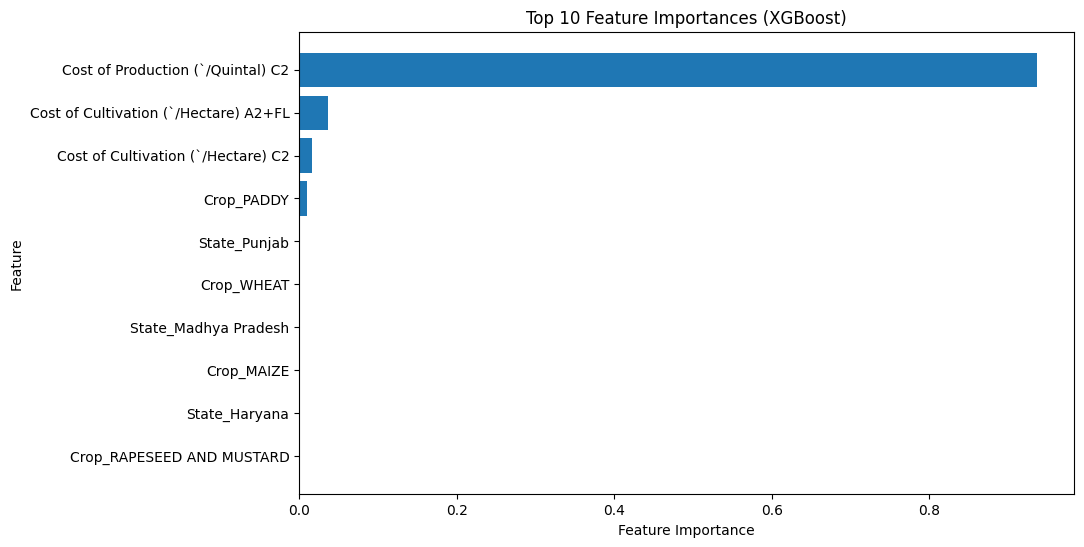

In [ ]:
# Step 11: Feature Importance (XGBoost)
importances_xgb = xgb_model.feature_importances_
indices_xgb = importances_xgb.argsort()[-10:] # Get top 10 features

plt.figure(figsize=(10,6))
plt.barh(range(len(indices_xgb)), importances_xgb[indices_xgb], align="center")
plt.yticks(range(len(indices_xgb)), [X.columns[i] for i in indices_xgb])
plt.title("Top 10 Feature Importances (XGBoost)")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.show()

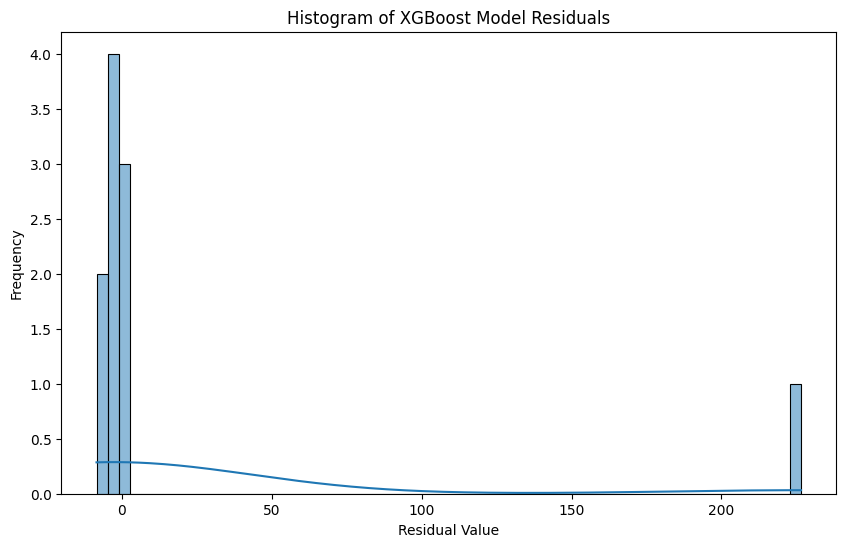

First 5 XGBoost residuals:
13      0.580079
45     -8.445667
47      0.589899
44    226.538745
17     -0.145834
Name: Yield (Quintal/ Hectare) , dtype: float64


In [ ]:
# Calculate residuals for XGBoost model
xgb_residuals = y_test - xgb_preds

# Plot histogram of XGBoost residuals
plt.figure(figsize=(10, 6))
sns.histplot(xgb_residuals, kde=True)
plt.title('Histogram of XGBoost Model Residuals')
plt.xlabel('Residual Value')
plt.ylabel('Frequency')
plt.show()

print("First 5 XGBoost residuals:")
print(xgb_residuals.head())

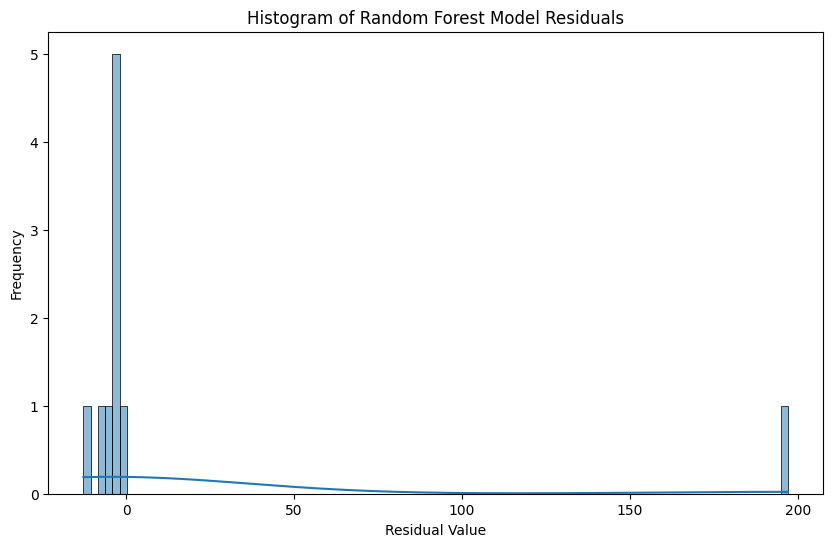

First 5 Random Forest residuals:
13     -0.7408
45    -12.7951
47     -3.7206
44    197.0867
17     -2.1187
Name: Yield (Quintal/ Hectare) , dtype: float64


In [ ]:
# Calculate residuals for Random Forest model
rf_residuals = y_test - rf_preds

# Plot histogram of Random Forest residuals
plt.figure(figsize=(10, 6))
sns.histplot(rf_residuals, kde=True)
plt.title('Histogram of Random Forest Model Residuals')
plt.xlabel('Residual Value')
plt.ylabel('Frequency')
plt.show()

print("First 5 Random Forest residuals:")
print(rf_residuals.head())

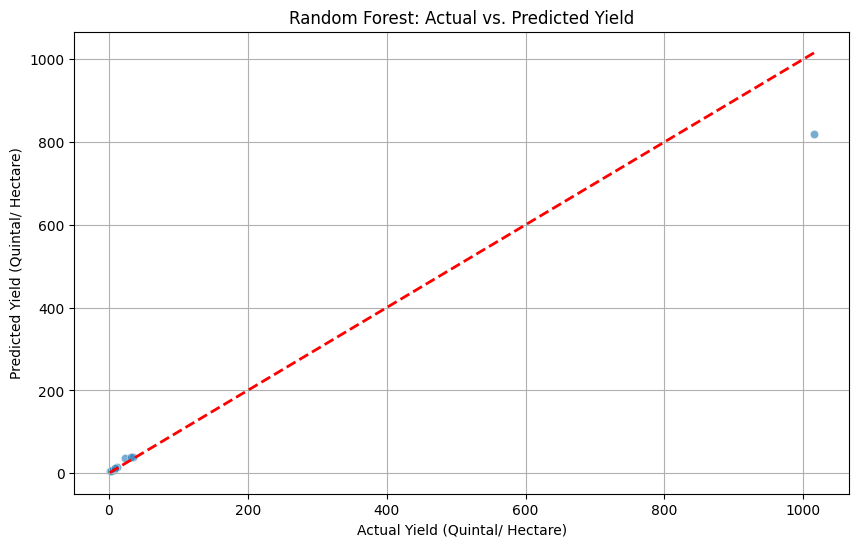

In [ ]:
# Scatter plot for Random Forest: Actual vs. Predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=rf_preds, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Random Forest: Actual vs. Predicted Yield')
plt.xlabel('Actual Yield (Quintal/ Hectare)')
plt.ylabel('Predicted Yield (Quintal/ Hectare)')
plt.grid(True)
plt.show()

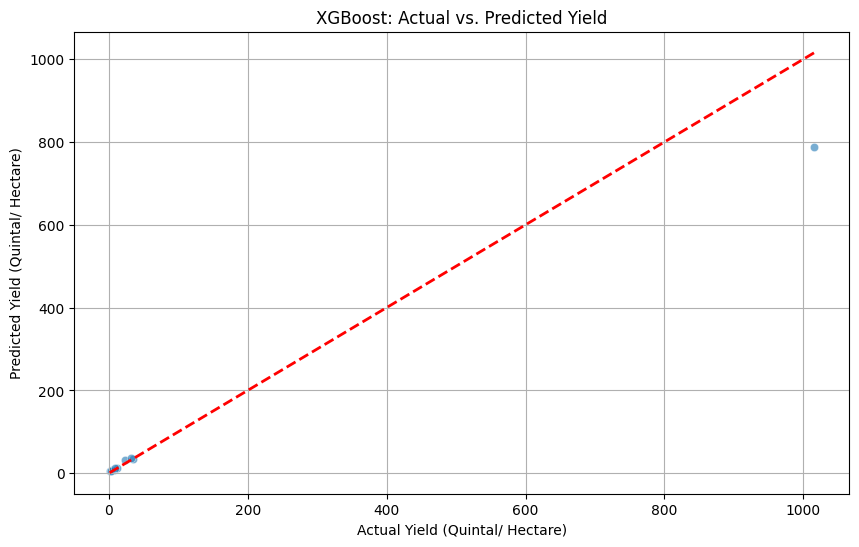

In [ ]:
# Scatter plot for XGBoost: Actual vs. Predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=xgb_preds, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('XGBoost: Actual vs. Predicted Yield')
plt.xlabel('Actual Yield (Quintal/ Hectare)')
plt.ylabel('Predicted Yield (Quintal/ Hectare)')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.model_selection import KFold

# Define the number of folds for cross-validation
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Lists to store results for Random Forest
rf_rmse_scores = []
rf_r2_scores = []

# Lists to store results for XGBoost
xgb_rmse_scores = []
xgb_r2_scores = []

print(f"Performing {n_splits}-fold cross-validation...")

for fold, (train_index, test_index) in enumerate(kf.split(X, y)):
    print(f"\n--- Fold {fold+1}/{n_splits} ---")
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    # Random Forest Model Training and Evaluation
    rf_model_cv = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_model_cv.fit(X_train_fold, y_train_fold)
    rf_preds_cv = rf_model_cv.predict(X_test_fold)

    rf_rmse = np.sqrt(mean_squared_error(y_test_fold, rf_preds_cv))
    rf_r2 = r2_score(y_test_fold, rf_preds_cv)
    rf_rmse_scores.append(rf_rmse)
    rf_r2_scores.append(rf_r2)
    print(f"Random Forest - RMSE: {rf_rmse:.4f}, R2: {rf_r2:.4f}")

    # XGBoost Model Training and Evaluation
    xgb_model_cv = XGBRegressor(n_estimators=100, random_state=42)
    xgb_model_cv.fit(X_train_fold, y_train_fold)
    xgb_preds_cv = xgb_model_cv.predict(X_test_fold)

    xgb_rmse = np.sqrt(mean_squared_error(y_test_fold, xgb_preds_cv))
    xgb_r2 = r2_score(y_test_fold, xgb_preds_cv)
    xgb_rmse_scores.append(xgb_rmse)
    xgb_r2_scores.append(xgb_r2)
    print(f"XGBoost - RMSE: {xgb_rmse:.4f}, R2: {xgb_r2:.4f}")

# Display cross-validation results
print(f"\n--- Cross-Validation Results ({n_splits} folds) ---")
print("Random Forest Mean RMSE: {:.4f} (Std: {:.4f})".format(np.mean(rf_rmse_scores), np.std(rf_rmse_scores)))
print("Random Forest Mean R2: {:.4f} (Std: {:.4f})".format(np.mean(rf_r2_scores), np.std(rf_r2_scores)))
print("\nXGBoost Mean RMSE: {:.4f} (Std: {:.4f})".format(np.mean(xgb_rmse_scores), np.std(xgb_rmse_scores)))
print("XGBoost Mean R2: {:.4f} (Std: {:.4f})".format(np.mean(xgb_r2_scores), np.std(xgb_r2_scores)))

Performing 5-fold cross-validation...

--- Fold 1/5 ---
Random Forest - RMSE: 71.7749, R2: 0.9430
XGBoost - RMSE: 71.7323, R2: 0.9430

--- Fold 2/5 ---
Random Forest - RMSE: 47.1248, R2: 0.9759
XGBoost - RMSE: 314.9935, R2: -0.0757

--- Fold 3/5 ---
Random Forest - RMSE: 22.8404, R2: 0.9888
XGBoost - RMSE: 12.8833, R2: 0.9964

--- Fold 4/5 ---
Random Forest - RMSE: 2.3660, R2: 0.8774
XGBoost - RMSE: 11.0975, R2: -1.6980

--- Fold 5/5 ---
Random Forest - RMSE: 32.1702, R2: 0.9807
XGBoost - RMSE: 128.5425, R2: 0.6925

--- Cross-Validation Results (5 folds) ---
Random Forest Mean RMSE: 35.2552 (Std: 23.3235)
Random Forest Mean R2: 0.9532 (Std: 0.0410)

XGBoost Mean RMSE: 107.8498 (Std: 112.2682)
XGBoost Mean R2: 0.1717 (Std: 1.0103)


Synthetic Time-Series Data for Prophet (ARHAR Crop):


,ds,y
0,2018-01-01,9.83
1,2018-02-01,7.47
2,2018-03-01,9.59
3,2018-04-01,6.42
4,2018-05-01,8.72


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.


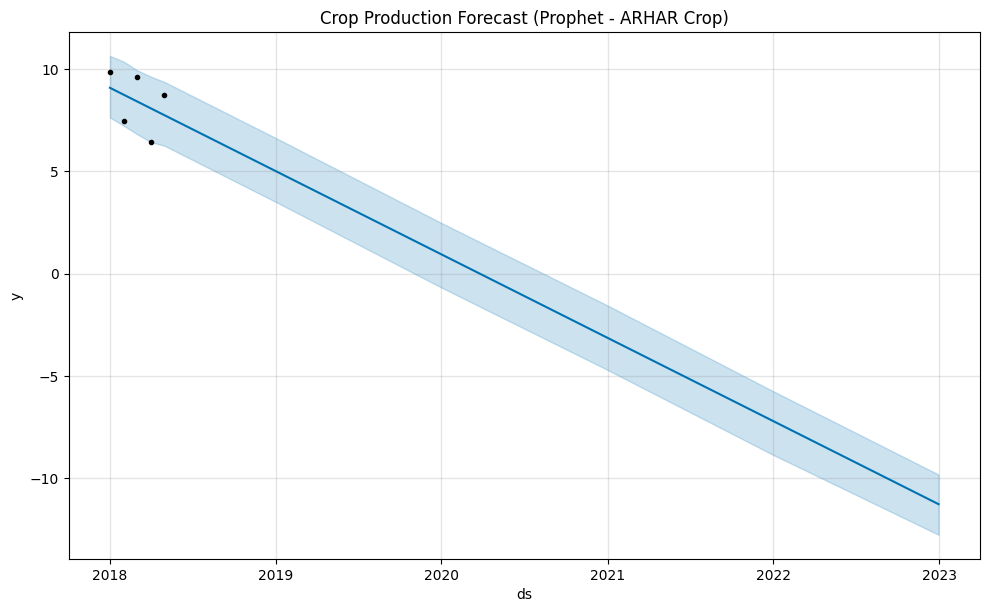

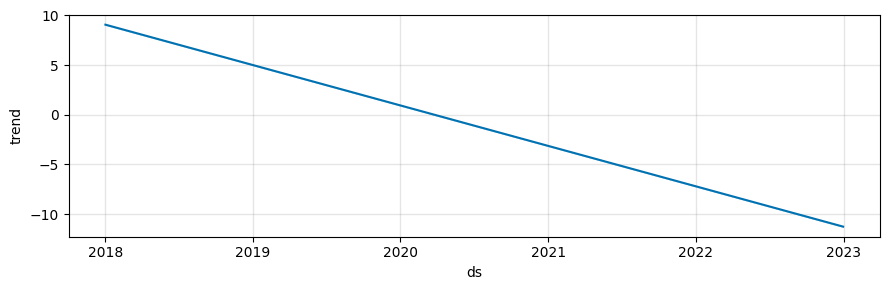

In [ ]:
# Step 1: Install Prophet (if not already installed)
!pip install prophet

# Step 2: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

# Explanation: The original DataFrame 'df' is cross-sectional and does not have
# 'production_year' or 'production' columns suitable for time series forecasting.
# To demonstrate Prophet, we need to create a synthetic time series from a subset
# of the data and assign artificial dates, similar to the previous demonstration.

# Filter for a specific crop (e.g., 'ARHAR') to create a time series for demonstration
# Ensure 'Crop' and 'Yield (Quintal/ Hectare) ' columns exist in df
if 'Crop' in df.columns and 'Yield (Quintal/ Hectare) ' in df.columns:
    arhar_df_for_prophet = df[df['Crop'] == 'ARHAR'].copy()

    if not arhar_df_for_prophet.empty:
        # Create a synthetic date range for the 'ds' column
        # Using 'MS' for month start frequency to avoid FutureWarning from 'M'
        start_date = pd.to_datetime('2018-01-01')
        dates = pd.date_range(start=start_date, periods=len(arhar_df_for_prophet), freq='MS')
        arhar_df_for_prophet['ds'] = dates

        # Rename 'Yield (Quintal/ Hectare) ' to 'y' for Prophet
        arhar_df_for_prophet['y'] = arhar_df_for_prophet['Yield (Quintal/ Hectare) ']

        # Select only the required columns for Prophet
        df_prophet = arhar_df_for_prophet[['ds', 'y']]

        print("Synthetic Time-Series Data for Prophet (ARHAR Crop):")
        display(df_prophet.head())

        # Step 5: Initialize and fit Prophet model
        model = Prophet()
        model.fit(df_prophet)

        # Step 6: Create future dataframe (forecast horizon)
        # Forecast for a reasonable period based on the synthetic data length
        future = model.make_future_dataframe(periods=5, freq='YE')  # forecast next 5 years
        forecast = model.predict(future)

        # Step 7: Plot forecast
        fig1 = model.plot(forecast)
        plt.title("Crop Production Forecast (Prophet - ARHAR Crop)")
        plt.show()

        # Step 8: Plot forecast components (trend, yearly seasonality)
        fig2 = model.plot_components(forecast)
        plt.show()
    else:
        print("No data found for 'ARHAR' crop to create a synthetic time series in this cell.")
else:
    print("""Required columns 'Crop' or 'Yield (Quintal/ Hectare) ' not found in the DataFrame 'df'. Cannot perform Prophet demonstration.
           Please ensure the 'df' is loaded correctly with these columns.""")

In [ ]:
# Install Prophet library
!pip install prophet

Synthetic Time-Series Data for Prophet (ARHAR Crop):


/tmp/ipykernel_2768/3526158280.py:16: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start=start_date, periods=len(arhar_df), freq='M')


,ds,y
0,2018-01-31,9.83
1,2018-02-28,7.47
2,2018-03-31,9.59
3,2018-04-30,6.42
4,2018-05-31,8.72


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.



Prophet Forecast:


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


,ds,yhat,yhat_lower,yhat_upper
0,2018-01-31,9.023959,7.534676,10.716013
1,2018-02-28,8.731048,7.307656,10.315103
2,2018-03-31,8.406753,6.792647,9.920807
3,2018-04-30,8.092920,6.599914,9.755602
4,2018-05-31,7.768625,6.128259,9.268223


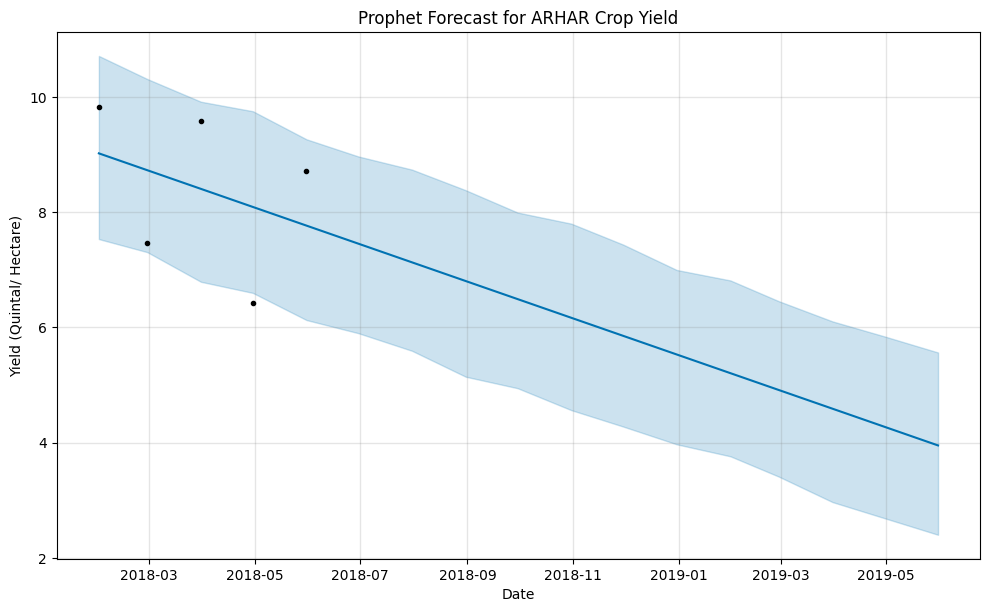

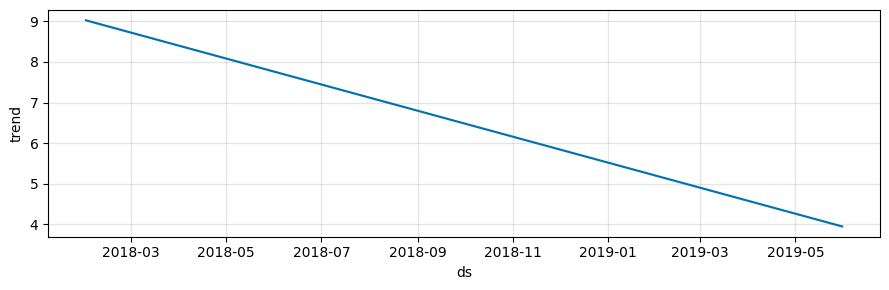

In [ ]:
from prophet import Prophet

# Create a synthetic time series for demonstration
# Let's aggregate 'Yield (Quintal/ Hectare)' by 'Crop' and create a synthetic date range.

# We'll take 'ARHAR' crop as an example for time-series forecasting.
# First, ensure 'Crop' column is available in original df
if 'Crop' not in df.columns:
    print("Error: 'Crop' column not found in the DataFrame.")
else:
    arhar_df = df[df['Crop'] == 'ARHAR'].copy()
    if not arhar_df.empty:
        # Create a synthetic date range. Let's say we have monthly data for 5 years.
        # Since we only have 5 entries for ARHAR, we'll assign 5 distinct months.
        start_date = pd.to_datetime('2018-01-01')
        dates = pd.date_range(start=start_date, periods=len(arhar_df), freq='M')
        arhar_df['ds'] = dates
        arhar_df['y'] = arhar_df['Yield (Quintal/ Hectare) ']

        # Select only the required columns for Prophet
        prophet_df = arhar_df[['ds', 'y']]

        print("Synthetic Time-Series Data for Prophet (ARHAR Crop):")
        display(prophet_df.head())

        # Initialize Prophet model
        model = Prophet()

        # Fit the model
        model.fit(prophet_df)

        # Create a future dataframe for predictions
        future = model.make_future_dataframe(periods=12, freq='M') # Forecast for next 12 months

        # Make predictions
        forecast = model.predict(future)

        print("\nProphet Forecast:")
        display(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())

        # Plot the forecast
        fig = model.plot(forecast)
        plt.title('Prophet Forecast for ARHAR Crop Yield')
        plt.xlabel('Date')
        plt.ylabel('Yield (Quintal/ Hectare)')
        plt.show()

        # Plot the components of the forecast (trend, seasonality)
        fig2 = model.plot_components(forecast)
        plt.show()
    else:
        print("No data found for 'ARHAR' crop to create a time series.")
